# 05 - EDA inicial

**Objetivo.** Realizar una primera exploración de la base consolidada limpia, con foco en cobertura, precios, superficie, distribución territorial y atributos de publicación. Este notebook no usa fuentes externas todavía.

In [1]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de base consolidada más avanzada disponible

In [ ]:
BASE_CONSOLIDADA_CANDIDATES = [
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_outliers_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_post_ajustes_con_flags_nulos_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_flags_nulos_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_v1.csv',
]

DATASETS_PIPELINE = [
    'df_preprocesado_meli_alq',
    'df_preprocesado_meli_alq_temp',
    'df_preprocesado_meli_vtas',
    'df_preprocesado_airbnb_temp',
    'df_preprocesado_argenprop_vtas',
    'df_preprocesado_argenprop_alq',
    'df_preprocesado_zonaprop_vtas',
    'df_preprocesado_zonaprop_alq',
]

CANONICAL_COLS = [
    'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url', 'fecha_extraccion',
    'scraped_at_utc', '_archivo_origen', 'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda',
    'precio', 'precio_texto', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio',
    'barrio_norm', 'comuna', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle', 'altura',
    'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref', 'cocheras',
    'expensas', 'expensas_moneda'
]


def construir_base_consolidada_desde_individuales(processed_dir):
    frames = []
    fuentes_usadas = []

    for name in DATASETS_PIPELINE:
        candidates = [
            processed_dir / f'{name}_con_outliers_v1.csv',
            processed_dir / f'{name}_post_ajustes_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_v1.csv',
        ]
        source = next((path for path in candidates if path.exists()), None)
        if source is None:
            continue

        df = pd.read_csv(source, low_memory=False)
        cols = [
            col for col in df.columns
            if col in CANONICAL_COLS or col.endswith('_is_null') or col.endswith('_flag')
        ]
        tmp = df[cols].copy()
        tmp['dataset_preprocesado'] = name
        tmp['_archivo_base_usado'] = source.name
        frames.append(tmp)
        fuentes_usadas.append({'dataset': name, 'archivo': source.name, 'filas': len(tmp)})

    if not frames:
        raise FileNotFoundError('No existe base consolidada ni archivos individuales procesados. Ejecutar notebooks 02-04.')

    return pd.concat(frames, ignore_index=True, sort=False), pd.DataFrame(fuentes_usadas)


CONSOLIDATED_PATH = next((path for path in BASE_CONSOLIDADA_CANDIDATES if path.exists()), None)

if CONSOLIDATED_PATH is not None:
    df_eda = pd.read_csv(CONSOLIDATED_PATH, low_memory=False)
    print('Base usada:', CONSOLIDATED_PATH.relative_to(REPO_ROOT))
else:
    df_eda, fuentes_base_eda = construir_base_consolidada_desde_individuales(PROCESSED_DIR)
    print('Base construida desde archivos individuales procesados.')
    display(fuentes_base_eda)

print(df_eda.shape)
display(df_eda.head())


## Cobertura por fuente y operación

In [3]:
display(pd.crosstab(df_eda['fuente_norm'], df_eda['tipo_operacion_norm'], dropna=False))

tipo_operacion_norm,alquiler,alquiler_temporal,venta
fuente_norm,,,
airbnb,0,9596,0
argenprop,80,0,82
mercado_libre,11479,6190,44013
zonaprop,495,0,485


## Cobertura territorial

,publicaciones
barrio_norm,
palermo,8874
recoleta,5521
belgrano,4122
caballito,3345
almagro,3275
nunez,3081
balvanera,2912
villa urquiza,2751
puerto madero,2743


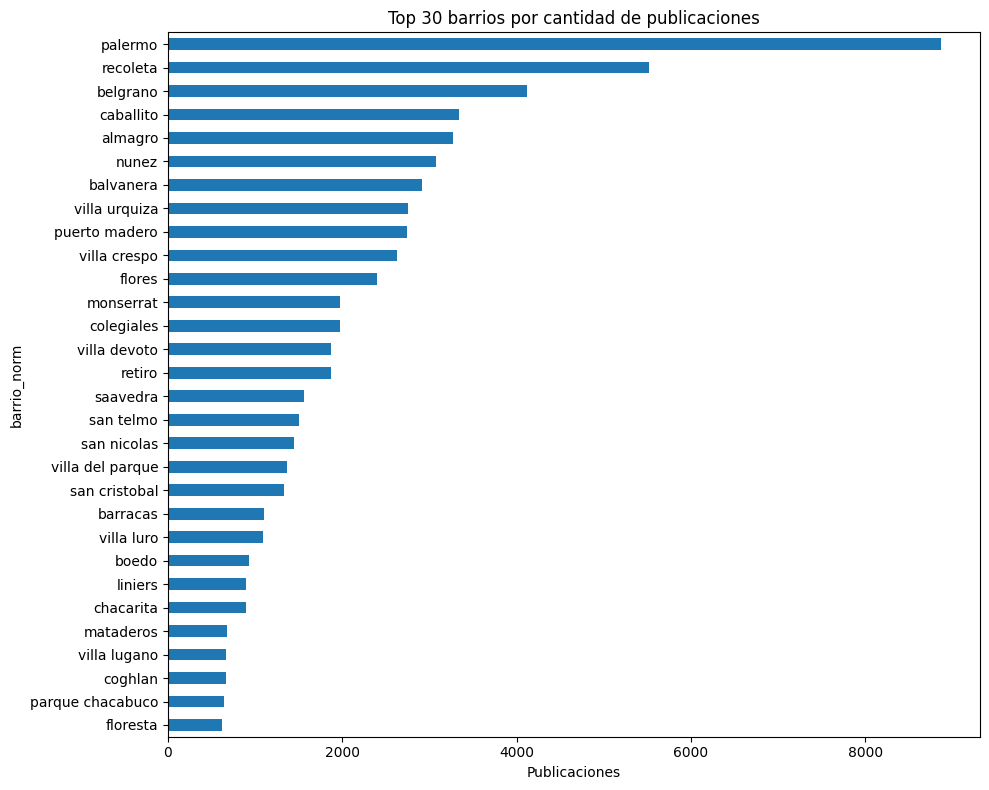

In [4]:
barrios = df_eda['barrio_norm'].value_counts(dropna=False).head(30)
display(barrios.to_frame('publicaciones'))

try:
    import matplotlib.pyplot as plt
    barrios.sort_values().plot(kind='barh', figsize=(10, 8), title='Top 30 barrios por cantidad de publicaciones')
    plt.xlabel('Publicaciones')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(exc)

## Calidad remanente de campos críticos

In [5]:
campos = ['precio', 'moneda_norm', 'barrio_norm', 'superficie_ref_m2', 'precio_m2_ref']
resumen_calidad = df_eda.groupby(['fuente_norm', 'tipo_operacion_norm'])[campos].apply(lambda x: x.isna().mean().mul(100).round(1))
display(resumen_calidad)

precio  moneda_norm  barrio_norm  superficie_ref_m2  precio_m2_ref
fuente_norm   tipo_operacion_norm                                                                    
airbnb        alquiler_temporal       0.0          0.0          0.8              100.0          100.0
argenprop     alquiler                0.0          0.0          0.0               11.2           11.2
              venta                   0.0          0.0          0.0                4.9            4.9
mercado_libre alquiler                0.0          0.0          0.2                0.4            0.4
              alquiler_temporal       0.0          0.0          0.4                0.4            0.4
              venta                   0.0          0.0          0.4                0.1            0.1
zonaprop      alquiler                0.0          0.0          0.0                0.8            0.8
              venta                   1.6          1.6          0.0                0.2            1.9

## Distribución inicial de precios por operación y moneda

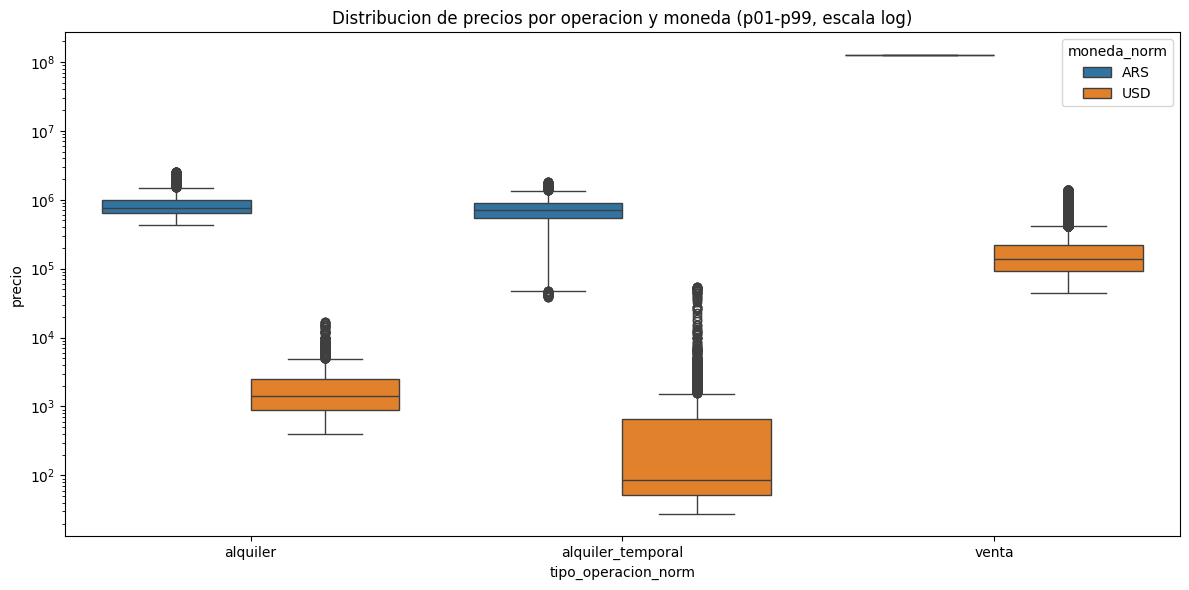

In [6]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False

plot_df = df_eda[df_eda['precio'].notna() & df_eda['moneda_norm'].notna()].copy()
plot_df = plot_df[plot_df['precio'] > 0]

partes_filtradas = []
for _, grupo in plot_df.groupby(['tipo_operacion_norm', 'moneda_norm']):
    q_low = grupo['precio'].quantile(0.01)
    q_high = grupo['precio'].quantile(0.99)
    partes_filtradas.append(grupo[grupo['precio'].between(q_low, q_high)])

plot_df = pd.concat(partes_filtradas, ignore_index=True) if partes_filtradas else pd.DataFrame()

if HAS_SEABORN and not plot_df.empty:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x='tipo_operacion_norm', y='precio', hue='moneda_norm')
    plt.yscale('log')
    plt.title('Distribucion de precios por operacion y moneda (p01-p99, escala log)')
    plt.tight_layout()
    plt.show()

## Precio por m2 y superficie

In [7]:
metricas = df_eda.groupby(['fuente_norm', 'tipo_operacion_norm', 'moneda_norm'])[['precio_m2_ref', 'superficie_ref_m2']].agg(['count', 'median', 'mean']).round(2)
display(metricas)

precio_m2_ref                         superficie_ref_m2               
                                                      count      median        mean             count median    mean
fuente_norm   tipo_operacion_norm moneda_norm                                                                       
airbnb        alquiler_temporal   USD                     0         NaN         NaN                 0    NaN     NaN
argenprop     alquiler            ARS                    58    19687.50    20895.48                58   40.5   48.90
                                  USD                    13       20.00       21.24                13  100.0  105.85
              venta               USD                    78     2852.40     2972.60                78   57.5   72.59
mercado_libre alquiler            ARS                  8197    19626.17    21359.21              8197   40.0   47.22
                                  USD                  3232       21.21       72.18              3232   65.0   89.48
              alquiler_temporal   ARS                  1800    18313.00    18464.87              1800   40.0   43.60
                                  USD                  4365       21.43      115.02              4365   45.0   54.00
              venta               ARS                     3  4069488.37  2904135.78                 3   43.0   44.67
                                  USD                 43968     2693.02     3024.87             43968   52.0   81.20
zonaprop      alquiler            ARS                   153    19047.62    19002.05               153   42.0   51.56
                                  USD                   338       18.71       20.28               338   67.0   95.49
              venta               USD                   476     2614.87     2944.64               476   76.0  113.36

## Atributos y amenities comparables

In [8]:
amenity_cols = [c for c in ['balcon', 'balcon_o_patio', 'terraza', 'pileta', 'parrilla', 'cochera', 'cochera_mencionada', 'amenities_mencionadas'] if c in df_eda.columns]
if amenity_cols:
    resumen_amenities = df_eda.groupby(['fuente_norm', 'tipo_operacion_norm'])[amenity_cols].mean(numeric_only=True).mul(100).round(1)
    display(resumen_amenities)

## Cierre EDA inicial

Completar con interpretación luego de revisar las salidas:

- fuentes/operaciones con mejor cobertura;
- barrios con volumen suficiente;
- campos críticos con limitaciones;
- primeras señales descriptivas para hipótesis;
- análisis que pasan a fuentes externas.